In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"

[2025年02月15日 17时28分12秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

AnnData object with n_obs × n_vars = 926 × 1128
    obs: 'c', 'milestone_color', 'milestone'
    var: 'feature_id', 'housekeeping'
    uns: 'cfe', 'pca', 'tsne', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_tsne', 'milestone_network_emb'
    varm: 'PCs'
    layers: 'expression', 'counts'

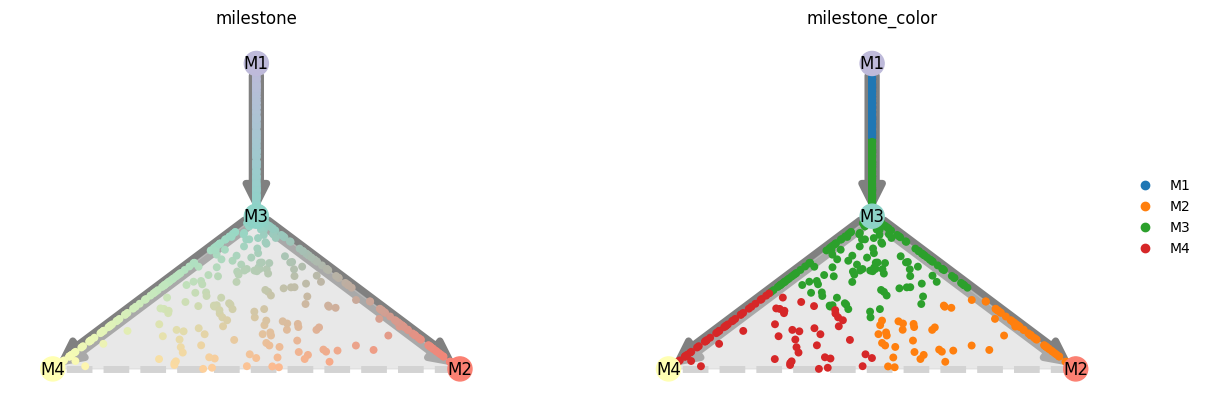

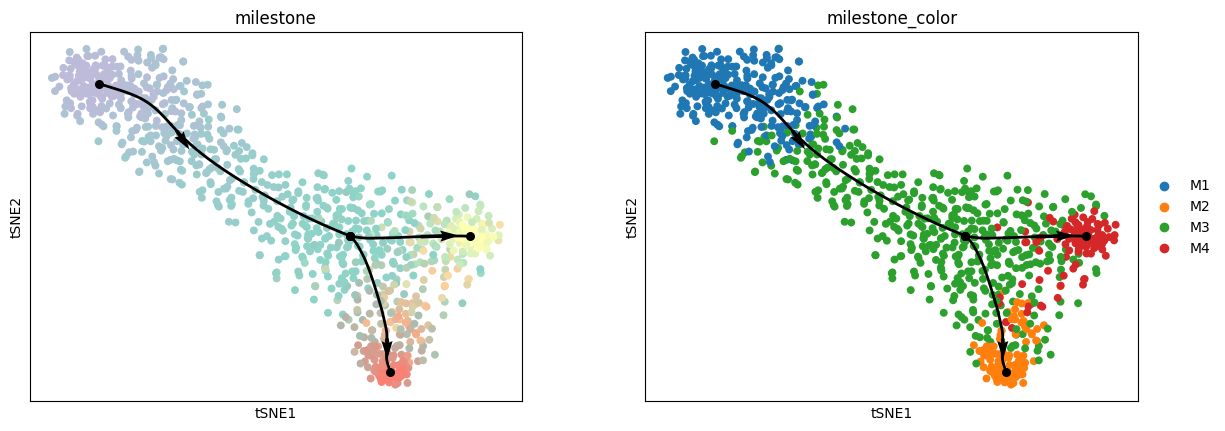

In [2]:
fadata = cfe.data.FateAnnData.read_dynverse_simulation_data()

cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color
sc.tl.tsne(fadata)

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)
fadata

Method and plot

[2025年02月15日 17时28分23秒] INFO     method_backend:                                                             
                                       <cfe.method.fate_dynverse_docker_backend.DynverseDockerBackend object at    
                                       0x740237e83ac0>                                                             


<Axes: title={'center': 'milestone_color'}, xlabel='tSNE1', ylabel='tSNE2'>

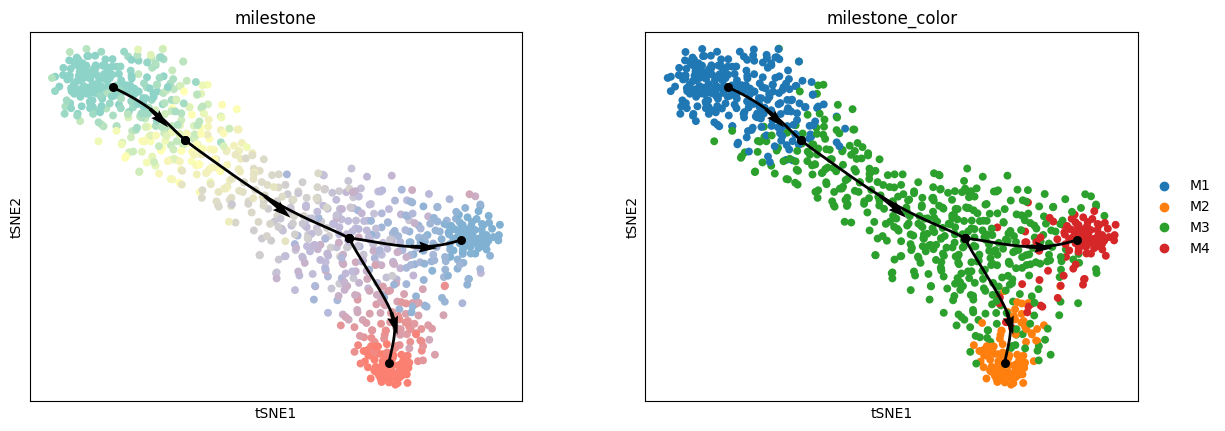

In [3]:
slingshot = cfe.method.FateMethod(method_name="slingshot", backend="dynverse_docker")

slingshot.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)

[2025年02月15日 17时28分38秒] INFO     Loaded function: <function cf_paga at 0x74021cd5fbe0> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x74020e19dab0>                                                                   
Normalized count data: X.
Logarithmized X.


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_paga.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  branches["length"] = adata.obs[[cluster_key, "dpt_pseudotime"]].groupby(cluster_key).apply(lambda x: x["dpt_pseudotime"].max() - x["dpt_pseudotime"].min() + epsilon).reset_index()[0]
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply

<Axes: title={'center': 'milestone_color'}, xlabel='tSNE1', ylabel='tSNE2'>

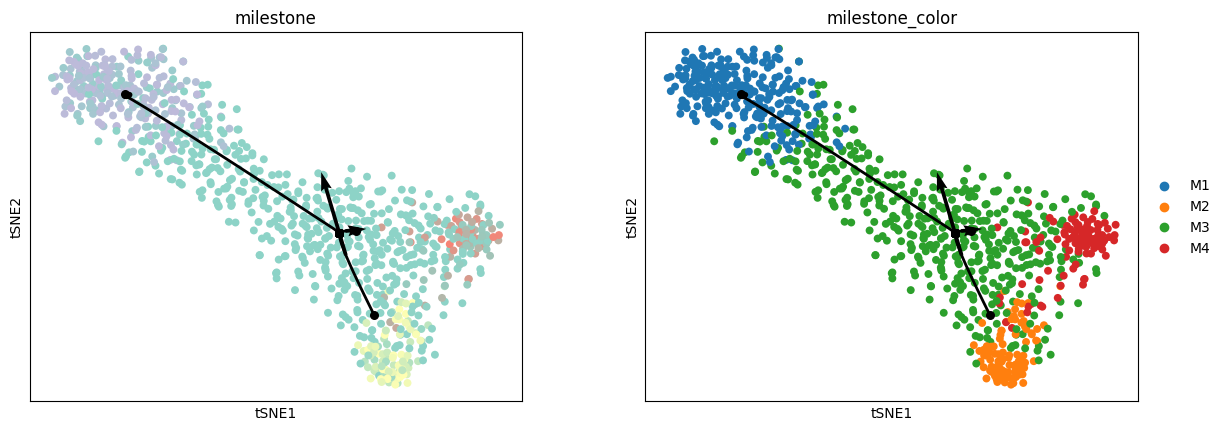

In [4]:
# TODO: PAGA need to be optimized, disconnected graph
paga_method = cfe.method.FateMethod(method_name="paga")

prior_information = {
    "start_id": "C1",
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.05}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
paga_method.infer_trajectory(fadata, parameters=parameters)

cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)

[2025年02月15日 17时28分46秒] INFO     Loaded function: <function cf_comp1 at 0x74020e149870> from                 
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_comp1.py                                                              
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x740227b3f8b0>                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percentages.groupby("cell_id").apply(lambda mpg: mix_color(mpg))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

<Axes: title={'center': 'milestone_color'}, xlabel='tSNE1', ylabel='tSNE2'>

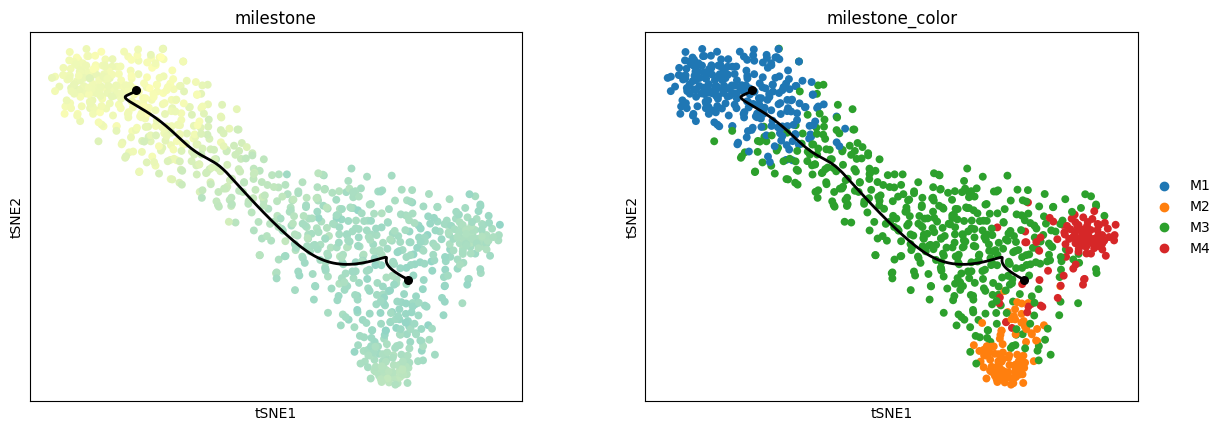

In [5]:
comp1_method = cfe.method.FateMethod(method_name="comp1")

comp1_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)

[2025年02月15日 17时28分51秒] INFO     Loaded function: <function cf_mst at 0x74020da6e560> from                   
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_mst.py                                                                
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x74022098fdf0>                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_mst.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  centers = np.array(list(adata.obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percen

<Axes: title={'center': 'milestone_color'}, xlabel='tSNE1', ylabel='tSNE2'>

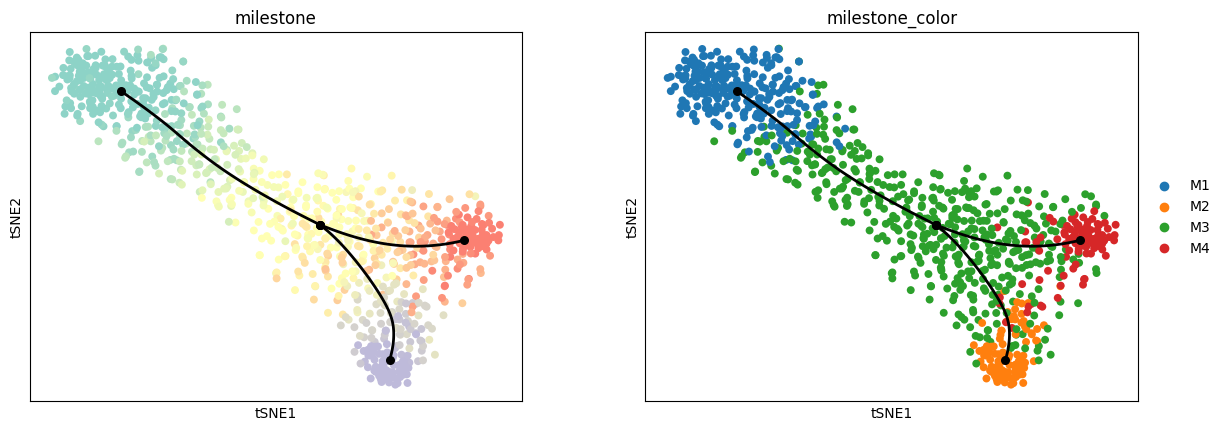

In [6]:
# TODO: MST need to be optimized
mst_method = cfe.method.FateMethod(method_name="mst", backend="python_function")

prior_information = {
    "groups_id": fadata.obs[cluster_key].tolist()
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

mst_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)

## 指标

In [10]:
parsed_model_name_list = fadata.get_all_model_name()
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list
# model_name_list = model_name_list[:-1] # TODO: 最后一个mst指标暂时会出错， 原因在于对于无向图的简化操作会报错

[2025年02月15日 17时29分19秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'slingshot-dynverse_docker',
  'paga-python_function',
  'comp1-python_function',
  'mst-python_function'],
 ['ref',
  '20250215_172823__slingshot-dynverse_docker__1o8Sk4PdBZ',
  '20250215_172838__paga-python_function__ND9D9apmaG',
  '20250215_172846__comp1-python_function__DYwrOuymLq',
  '20250215_172851__mst-python_function__vwp8pKDAkP'])

In [11]:
metrics = cfe.metric.metrics
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

['edge_flip', 'him', 'isomorphic']

In [12]:
import pandas as pd


model_metric_dict = {}

for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df

,isomorphic,edge_flip,him
ref,1,0,0
20250215_172823__slingshot-dynverse_docker__1o8Sk4PdBZ,1,0,0
20250215_172838__paga-python_function__ND9D9apmaG,0,0,0
20250215_172846__comp1-python_function__DYwrOuymLq,0,0,0
20250215_172851__mst-python_function__vwp8pKDAkP,1,0,0
